# Synthetic data file roundtrip

Notebook version of docs/synthetic_data_file_roundtrip.md using the executable example helper.

In [ ]:
import warnings
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyoifits as oifits
from jax.flatten_util import ravel_pytree

warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_value

from pathlib import Path
import sys

from drpangloss.plotting import (
    posterior_predictive_summary,
    plot_data_model_correlation,
    plot_chainconsumer_diagnostics,
    plot_recovery_residuals,
    diagnostics_table_from_samples,
    truth_cartesian_and_polar,
)

notebook_dir = (
    (Path.cwd() / "notebooks")
    if (Path.cwd() / "notebooks").exists()
    else Path.cwd()
)
if str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))

from tutorial_helpers import find_repo_root, load_synthetic_workflow_module

repo_root = find_repo_root()
module = load_synthetic_workflow_module(repo_root)

run_synthetic_binary_demo = module.run_synthetic_binary_demo
within_two_sigma = module.within_two_sigma
fisher_within_three_sigma = module.fisher_within_three_sigma

In [2]:
out = (
    repo_root / "docs" / "generated" / "synthetic_binary_from_notebook.oifits"
).resolve()
summary = run_synthetic_binary_demo(out)
summary



### OIFITS CREATED (synthetic_binary_from_notebook.oifits).


W0303 22:42:46.194978 2506260 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


RecoverySummary(truth={'dra': 110.0, 'ddec': -70.0, 'flux': 0.0032}, grid_estimate={'dra': 99.0, 'ddec': -66.0, 'flux': 0.0036069736815989017}, hmc_median={'dra': 100.57429504394531, 'ddec': -66.22709655761719, 'flux': 0.0034537953324615955}, hmc_std={'dra': 4.655518531799316, 'ddec': 3.7644033432006836, 'flux': 0.00018507087952457368}, fisher_hmc_median={'dra': 100.7736587524414, 'ddec': -66.27662658691406, 'flux': 0.003446513321250677}, fisher_hmc_std={'dra': 4.612907409667969, 'ddec': 3.6174638271331787, 'flux': 0.00017996276437770575}, noise_settings={'visamp_err_frac': 0.002, 'visphi_err_frac': 0.004, 'vis2_err_frac': 0.001, 'cp_err_frac': 0.004}, output_file='/Users/benpope/code/drpangloss/docs/generated/synthetic_binary_from_notebook.oifits')

## 1) Execute the synthetic roundtrip workflow
Generate a synthetic OIFITS product, reload it, and collect recovery summaries from grid, HMC, and Fisher-HMC runs.

In [3]:
checks = within_two_sigma(summary)
fisher_checks = fisher_within_three_sigma(summary)
checks, fisher_checks

({'dra': True, 'ddec': True, 'flux': True},
 {'dra': True, 'ddec': True, 'flux': True})

## 2) Full posterior diagnostics
Re-run explicit HMC and Fisher-HMC samplers on the saved file and compare them in shared Cartesian and polar diagnostic views.

Both samplers are overlaid with the same plotting recipe in each coordinate system, so differences are attributable to inference behavior rather than layout changes.

## Synthetic noise assumptions

- `VIS2ERR` is in absolute $V^2$ units (not percent).
- `VISPHIERR` and `T3PHIERR` are in **degrees**.
- The synthetic helper now uses tighter default errors to make HMC recovery identifiable for this toy contrast level.

In [3]:
loaded = oifits.open(summary.output_file)
oidata = module.OIData(loaded)
params = ["dra", "ddec", "flux"]


# Vanilla HMC model in physical coordinates with bounded priors.
def model_hmc(data_obj):
    dra = numpyro.sample("dra", dist.Uniform(-250.0, 250.0))
    ddec = numpyro.sample("ddec", dist.Uniform(-250.0, 250.0))
    log10_flux = numpyro.sample("log10_flux", dist.Uniform(-6.0, -1.0))
    flux = 10.0**log10_flux
    numpyro.factor(
        "loglike",
        module.loglike(
            [dra, ddec, flux], params, data_obj, module.BinaryModelCartesian
        ),
    )


init_values = {
    "dra": float(summary.grid_estimate["dra"]),
    "ddec": float(summary.grid_estimate["ddec"]),
    "log10_flux": float(np.log10(max(summary.grid_estimate["flux"], 1e-12))),
}
mcmc = MCMC(
    NUTS(model_hmc, init_strategy=init_to_value(values=init_values)),
    num_warmup=800,
    num_samples=2000,
    num_chains=1,
    progress_bar=False,
)
mcmc.run(jax.random.PRNGKey(2026), data_obj=oidata)
post_hmc = mcmc.get_samples()

# Fisher geometry around the grid estimate for latent-space whitening.
x0_dict = {
    "dra": float(summary.grid_estimate["dra"]),
    "ddec": float(summary.grid_estimate["ddec"]),
    "log10_flux": float(np.log10(max(summary.grid_estimate["flux"], 1e-12))),
}
x0, unravel = ravel_pytree(x0_dict)


def objective(x):
    xdict = unravel(x)
    flux = 10.0 ** xdict["log10_flux"]
    values = jnp.array([xdict["dra"], xdict["ddec"], flux])
    return -module.loglike(values, params, oidata, module.BinaryModelCartesian)


fisher = module.fisher_matrix(objective, x0, ridge=1e-8)
proj = module.fisher_projection(fisher)


# Fisher-HMC in latent coordinates with prior correction back to physical priors.
def model_hmc_fisher(data_obj):
    u_latent = numpyro.sample(
        "u", dist.Normal(0.0, 1.0).expand([x0.shape[0]]).to_event(1)
    )
    log_q_u = dist.Normal(0.0, 1.0).log_prob(u_latent).sum()
    x = x0 + jnp.dot(proj, u_latent)
    xdict = unravel(x)
    dra = xdict["dra"]
    ddec = xdict["ddec"]
    log10_flux = xdict["log10_flux"]
    flux = 10.0**log10_flux
    numpyro.deterministic("dra", dra)
    numpyro.deterministic("ddec", ddec)
    numpyro.deterministic("flux", flux)
    log_prior_x = (
        dist.Uniform(-250.0, 250.0).log_prob(dra)
        + dist.Uniform(-250.0, 250.0).log_prob(ddec)
        + dist.Uniform(-6.0, -1.0).log_prob(log10_flux)
    )
    numpyro.factor("prior_correction", log_prior_x - log_q_u)
    numpyro.factor(
        "loglike",
        module.loglike(
            [dra, ddec, flux], params, data_obj, module.BinaryModelCartesian
        ),
    )


mcmc_f = MCMC(
    NUTS(model_hmc_fisher),
    num_warmup=800,
    num_samples=2000,
    num_chains=1,
    progress_bar=False,
)
mcmc_f.run(jax.random.PRNGKey(2027), data_obj=oidata)
post_f = mcmc_f.get_samples()

hmc_df = pd.DataFrame(
    {
        "dra": np.asarray(post_hmc["dra"]),
        "ddec": np.asarray(post_hmc["ddec"]),
        "flux": np.asarray(10.0 ** post_hmc["log10_flux"]),
    }
)
hmc_df["sep"] = np.sqrt(hmc_df["dra"] ** 2 + hmc_df["ddec"] ** 2)
hmc_df["pa"] = (
    np.degrees(np.arctan2(hmc_df["ddec"], hmc_df["dra"])) + 360.0
) % 360.0

fisher_df = pd.DataFrame(
    {
        "dra": np.asarray(post_f["dra"]),
        "ddec": np.asarray(post_f["ddec"]),
        "flux": np.asarray(post_f["flux"]),
    }
)
fisher_df["sep"] = np.sqrt(fisher_df["dra"] ** 2 + fisher_df["ddec"] ** 2)
fisher_df["pa"] = (
    np.degrees(np.arctan2(fisher_df["ddec"], fisher_df["dra"])) + 360.0
) % 360.0

truth_dict = summary.truth
truth_sep = float(np.sqrt(truth_dict["dra"] ** 2 + truth_dict["ddec"] ** 2))
truth_pa = float(
    (np.degrees(np.arctan2(truth_dict["ddec"], truth_dict["dra"])) + 360.0)
    % 360.0
)

{
    "hmc_rows": len(hmc_df),
    "fisher_rows": len(fisher_df),
    "truth_sep": truth_sep,
    "truth_pa": truth_pa,
}

{'hmc_rows': 2000,
 'fisher_rows': 2000,
 'truth_sep': 130.38404810405297,
 'truth_pa': 327.5288077091515}

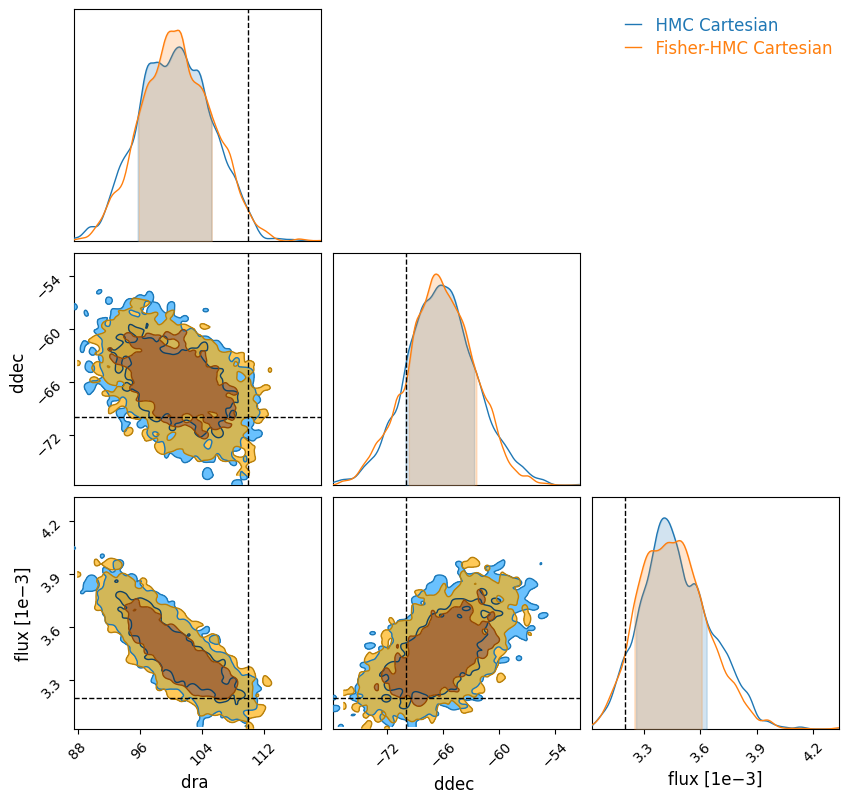

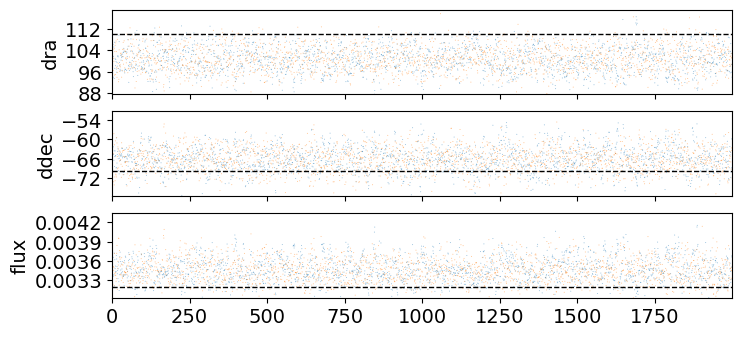

In [ ]:
# Cartesian comparison plot
plot_chainconsumer_diagnostics(
    {
        "HMC Cartesian": hmc_df,
        "Fisher-HMC Cartesian": fisher_df,
    },
    columns=["dra", "ddec", "flux"],
    truth=truth_dict,
    colors=["#1f77b4", "#ff7f0e"],
)
plt.show()

In [ ]:
# Polar comparison plot
plot_chainconsumer_diagnostics(
    {
        "HMC Polar": hmc_df,
        "Fisher-HMC Polar": fisher_df,
    },
    columns=["sep", "pa", "flux"],
    truth={"sep": truth_sep, "pa": truth_pa, "flux": truth_dict["flux"]},
    colors=["#1f77b4", "#ff7f0e"],
)
plt.show()

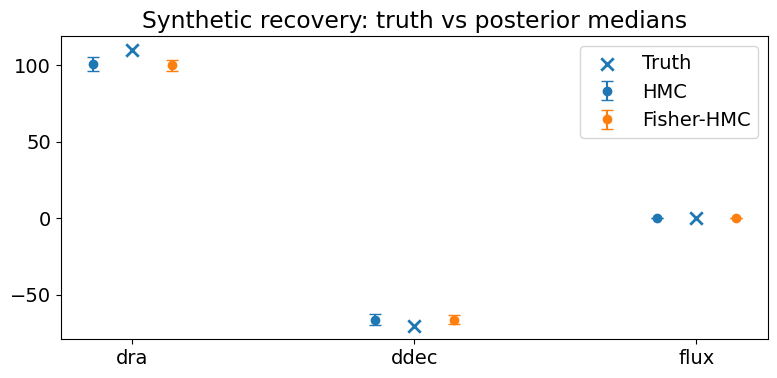

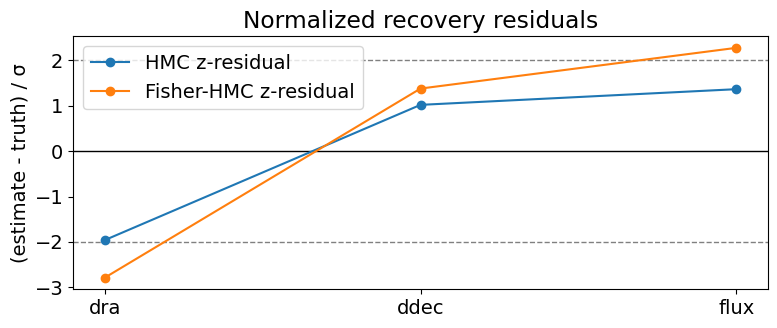

In [ ]:
params = ["dra", "ddec", "flux"]
truth = np.array([summary.truth[p] for p in params], dtype=float)
hmc = np.array([summary.hmc_median[p] for p in params], dtype=float)
hmc_std = np.array([summary.hmc_std[p] for p in params], dtype=float)
fisher = np.array([summary.fisher_hmc_median[p] for p in params], dtype=float)
fisher_std = np.array([summary.fisher_hmc_std[p] for p in params], dtype=float)

plot_recovery_residuals(
    params=params,
    truth=truth,
    estimates_by_label={
        "HMC": hmc,
        "Fisher-HMC": fisher,
    },
    std_by_label={
        "HMC": hmc_std,
        "Fisher-HMC": fisher_std,
    },
)
plt.show()

## 3) Recovery summary metrics
Visualize median recovery against truth and standardized residuals to quantify estimator quality.

A useful quick check is whether all parameters remain near zero in standardized residual space and whether Fisher-HMC and vanilla HMC tell a consistent recovery story.

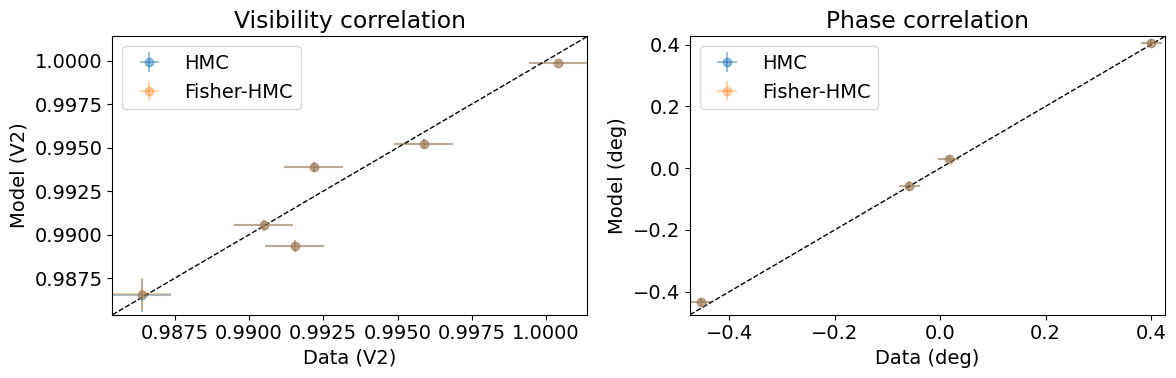

In [8]:
# Posterior predictive correlation: data vs model (HMC and Fisher-HMC)
hmc_pred = posterior_predictive_summary(
    np.asarray(post_hmc["dra"]),
    np.asarray(post_hmc["ddec"]),
    np.asarray(10.0 ** post_hmc["log10_flux"]),
    oidata,
    module.BinaryModelCartesian,
)

fisher_pred = posterior_predictive_summary(
    np.asarray(post_f["dra"]),
    np.asarray(post_f["ddec"]),
    np.asarray(post_f["flux"]),
    oidata,
    module.BinaryModelCartesian,
)

plot_data_model_correlation(
    oidata,
    {"HMC": hmc_pred, "Fisher-HMC": fisher_pred},
    colors=["C0", "C1"],
)
plt.show()

## 4) Posterior predictive correlation checks
Overlay model-vs-data correlation panels for visibility and phase, including uncertainty bars and $1\!:\!1$ lines.

These panels answer a practical question: do posterior samples reproduce the observables that actually drive inference, not just parameter medians.